# Warehouse analytics — chess.com marts

Connects directly to the platform **Postgres warehouse** (the dbt `marts` schema) — the same curated tables Superset and the WrenAI chatbot read — and runs a few analyses. Real data: 245 titled players, 12,255 games.

In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine
%matplotlib inline
uri = f"postgresql+psycopg2://{os.environ['PGUSER']}:{os.environ['PGPASSWORD']}"\
      f"@{os.environ['PGHOST']}:{os.environ['PGPORT']}/{os.environ['PGDATABASE']}"
eng = create_engine(uri)
pd.read_sql("select table_name from information_schema.tables where table_schema='marts' order by 1", eng)

,table_name
0,dim_date
1,dim_players
2,dim_time_class
3,fct_games
4,fct_player_monthly_activity
5,mart_daily_games
6,mart_growth_funnel
7,mart_player_segments
8,mart_rating_trend
9,mart_retention


## Average retention curve across cohorts

,months_since_join,avg_retention
0,0,1.000000
1,1,0.813786
2,2,0.718000
3,3,0.645929
4,4,0.630071
5,5,0.552643
6,6,0.588143
7,7,0.643714
8,8,0.546429
9,9,0.676769


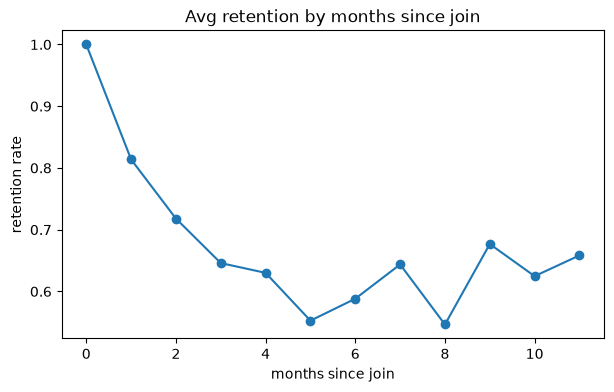

In [2]:
ret = pd.read_sql('select months_since_join, avg(retention_rate) as avg_retention '
                  'from marts.mart_retention group by 1 order by 1', eng)
ax = ret.plot(x='months_since_join', y='avg_retention', marker='o', legend=False,
              title='Avg retention by months since join', figsize=(7,4))
ax.set_ylabel('retention rate'); ax.set_xlabel('months since join')
ret.head(12)

## Players by recency segment

,recency_segment,players
0,active,144
1,churned,49
2,lapsing,33
3,at_risk,19


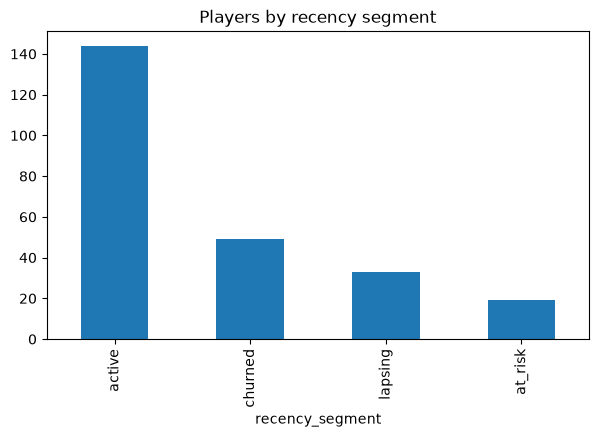

In [3]:
seg = pd.read_sql('select recency_segment, count(*) as players '
                  'from marts.mart_player_segments group by 1 order by 2 desc', eng)
seg.plot.bar(x='recency_segment', y='players', legend=False, title='Players by recency segment', figsize=(7,4))
seg

## Time-control performance

In [4]:
pd.read_sql('select time_class, rules, games, win_rate, avg_player_rating '
            'from marts.mart_time_class_performance order by games desc', eng)

,time_class,rules,games,win_rate,avg_player_rating
0,blitz,chess,9139,0.483,2699.0
1,bullet,chess,2484,0.516,2495.0
2,blitz,chess960,216,0.435,2087.0
3,blitz,bughouse,202,0.599,1790.0
4,rapid,chess,146,0.596,2221.0
5,bullet,chess960,31,0.677,2706.0
6,daily,chess,31,0.613,1780.0
7,blitz,oddschess,3,0.667,2385.0
8,rapid,oddschess,3,1.000,1647.0
